In [1]:
'''
always run this cell first
'''
import pandas as pd

# 2023-2024
# with same grid and tax fee as 2023:
# levels = {'summer weekday': [33.74, 28.82, 23.83],
#           'summer weekend': [30.18, 25.32, 18.16],
#           'winter weekday': [35.26, 29.86, 25.16],
#           'winter weekend': [31.47, 25.45, 18.57]}

# levels = {'summer weekday': [34.9, 30.1, 25.44],
#           'summer weekend': [31.66, 27.0, 19.7],
#           'winter weekday': [35.79, 30.5, 26.43],
#           'winter weekend': [32.84, 27.53, 19.94]}

# 2023 für Oslo
# levels = {'summer weekday': [34.79, 30.09, 26.24],
#           'summer weekend': [30.93, 26.54, 18.94],
#           'winter weekday': [37.29, 32.09, 26.91],
#           'winter weekend': [33.58, 27.88, 19.67]}

#2024
levels = {'summer weekday': [35.26, 30.41, 24.87],
          'summer weekend': [32.35, 27.46, 20.35],
          'winter weekday': [36.65, 31.78, 27.61],
          'winter weekend': [32.77, 27.73, 21.66]}

# 2024 Industrie
levels = {'summer weekday': [20.41, 15.84, 9.67],
          'summer weekend': [17.98, 13.75, 7.47],
          'winter weekday': [21.38, 16.60, 12.89],
          'winter weekend': [18.28, 13.95, 8.80]}

# 2024 Industrie ohne Wochenende
levels = {'summer': [18.77, 14.54, 7.87],
          'winter': [19.05, 14.02, 8.77]}

prices = pd.read_csv(r'C:\Users\fu\Downloads\Dokumente\Tariffmodelle\TG\2024_data_grouped_Industrie.csv', index_col=[0])

In [2]:
for i in prices.index:
    _levels = levels[prices.loc[i, 'group']]
    dynamic = prices.loc[i, 'Wholesale price corrected']
    nearest_level = min(_levels, key=lambda x: abs(x - dynamic))
    prices.loc[i, 'tariff'] = nearest_level

prices.to_csv(r'C:\Users\fu\Downloads\Dokumente\Tariffmodelle\TG\Datenanalyse\TG_Datenanalyser\result_ohne_Dauer_2024_Industrie_ohne_Trennung.csv')

In [53]:
# prices = pd.read_csv(r'C:\Users\fu\Downloads\Dokumente\Smart Tariffe\TG\Datenanalyse\TG_Datenanalyser\result_ohne_Dauer_2023_2024.csv')
# prices.index = pd.RangeIndex(start=0, stop=len(prices), step=1)

# '''
# Mind.Dauer einer Stufe = 2
# '''
# for t in prices.index[2:]:
#     if (prices.loc[t-1, 'tariff']!= prices.loc[t-2, 'tariff']) & (prices.loc[t, 'tariff'] != prices.loc[t-1, 'tariff']):
#         prices.loc[t, 'tariff'] = prices.loc[t-1, 'tariff']
        
# '''
# Mind.Dauer einer Stufe = 3
# '''
# for t in prices.index[3:]:
#     if (not prices.loc[t-1, 'tariff'] == prices.loc[t-2, 'tariff'] == prices.loc[t-3, 'tariff']) & \
#     (prices.loc[t, 'tariff'] != prices.loc[t-1, 'tariff']):
#         prices.loc[t, 'tariff'] = prices.loc[t-1, 'tariff']

# '''
# Mind.Dauer einer Stufe = 6
# '''
# for t in prices.index[6:]:
#     if (not prices.loc[t-1, 'tariff'] == prices.loc[t-2, 'tariff'] == prices.loc[t-3, 'tariff'] ==\
#         prices.loc[t-4, 'tariff'] == prices.loc[t-5, 'tariff'] == prices.loc[t-6, 'tariff']) &\
#         (prices.loc[t, 'tariff'] != prices.loc[t-1, 'tariff']):
#         prices.loc[t, 'tariff'] = prices.loc[t-1, 'tariff']
        
prices.to_csv(r'C:\Users\fu\Downloads\Dokumente\Smart Tariffe\TG\Datenanalyse\TG_Datenanalyser\result_mit_Dauer_1.csv')

In [59]:
'''
improved method
'''
min_dauer = 6

prices = pd.read_csv(r'C:/Users\fu/Downloads/Dokumente/Smart Tariffe/TG/Datenanalyse/TG_Datenanalyser/' + f'result_mit_Dauer_{min_dauer-1}.csv')
prices.index = pd.RangeIndex(start=0, stop=len(prices), step=1)

for t in prices.index[2:-(min_dauer-1)]:
    if (prices.loc[t, 'tariff'] != prices.loc[t-1, 'tariff']) and \
       not all(prices.loc[t, 'tariff'] == prices.loc[t+i, 'tariff'] for i in range(1, min_dauer)):
        prices.loc[t, 'tariff'] = prices.loc[t-1, 'tariff']
        
prices.to_csv('C:/Users/fu/Downloads/Dokumente/Smart Tariffe/TG/Datenanalyse/TG_Datenanalyser/' + f'result_mit_Dauer_{min_dauer}.csv')

Time
2024-12-10 00:00:00    winter weekday
2024-12-10 01:00:00    winter weekday
2024-12-10 02:00:00    winter weekday
2024-12-10 03:00:00    winter weekday
2024-12-10 04:00:00    winter weekday
2024-12-10 05:00:00    winter weekday
2024-12-10 06:00:00    winter weekday
2024-12-10 07:00:00    winter weekday
2024-12-10 08:00:00    winter weekday
2024-12-10 09:00:00    winter weekday
2024-12-10 10:00:00    winter weekday
2024-12-10 11:00:00    winter weekday
2024-12-10 12:00:00    winter weekday
2024-12-10 13:00:00    winter weekday
2024-12-10 14:00:00    winter weekday
2024-12-10 15:00:00    winter weekday
2024-12-10 16:00:00    winter weekday
2024-12-10 17:00:00    winter weekday
2024-12-10 18:00:00    winter weekday
2024-12-10 19:00:00    winter weekday
2024-12-10 20:00:00    winter weekday
2024-12-10 21:00:00    winter weekday
2024-12-10 22:00:00    winter weekday
2024-12-10 23:00:00    winter weekday
Name: group, dtype: object


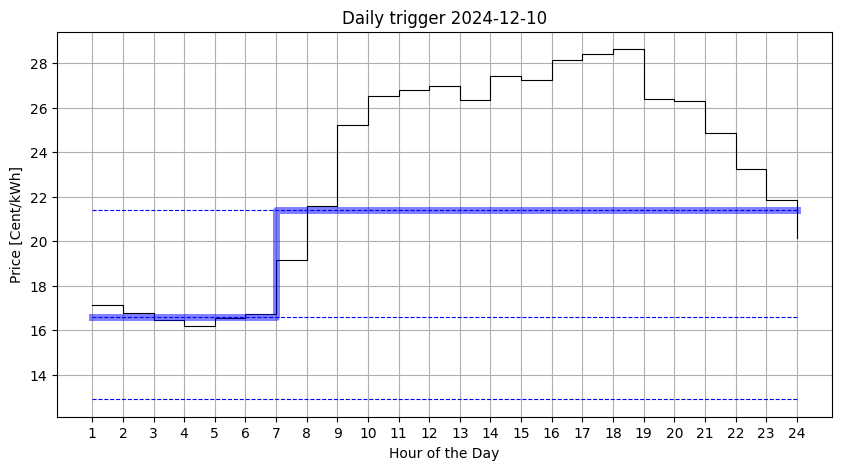

In [3]:
import matplotlib.pyplot as plt

def plot_daily(prices, tarif, day, dauer):
    prices.index = pd.to_datetime(prices.index)
    tarif.index = prices.index
    print(tarif.loc[day, 'group'])
    _levels = levels[tarif.loc[day, 'group'].iloc[0]]
    hours = list(range(1, 25))
    dynamic = prices.loc[day, 'Wholesale price corrected']
    tarif = tarif.loc[day, 'tariff']
    
    plt.figure(figsize=(10, 5))
    plt.step(hours, dynamic, where='post', color='black', linewidth=0.8) # dynamic prices step curve
    for level in _levels:
        plt.hlines(level, 1, 24, linestyles='dashed', colors='blue', linewidth=0.8) # 3 levels
    plt.step(hours, tarif, where='post', color='blue', alpha=0.5, linewidth=5)
    plt.xlabel('Hour of the Day')
    plt.ylabel('Price [Cent/kWh]')
    plt.title(f'Daily trigger {day}')
    plt.grid(True)
    plt.xticks(hours)
    # plt.savefig('C:/Users/fu/Downloads/Dokumente/Smart Tariffe/TG/Datenanalyse/TG_Datenanalyser/Pictures/trigger examples ' \
               # + f'{dauer}/' + f'Daily trigger {day}.png')
    plt.show()

#tarif_Dauer_6 = pd.read_csv(r'C:\Users\fu\Downloads\Dokumente\Smart Tariffe\TG\Datenanalyse\TG_Datenanalyser\result_mit_Dauer_6.csv', index_col=[0])
#tarif_Dauer_5 = pd.read_csv(r'C:\Users\fu\Downloads\Dokumente\Smart Tariffe\TG\Datenanalyse\TG_Datenanalyser\result_mit_Dauer_5.csv', index_col=[0])
#tarif_Dauer_4 = pd.read_csv(r'C:\Users\fu\Downloads\Dokumente\Smart Tariffe\TG\Datenanalyse\TG_Datenanalyser\result_mit_Dauer_4.csv', index_col=[0])
#tarif_Dauer_3 = pd.read_csv(r'C:\Users\fu\Downloads\Dokumente\Smart Tariffe\TG\Datenanalyse\TG_Datenanalyser\result_mit_Dauer_3.csv', index_col=[0])
#tarif_Dauer_2 = pd.read_csv(r'C:\Users\fu\Downloads\Dokumente\Smart Tariffe\TG\Datenanalyse\TG_Datenanalyser\result_mit_Dauer_2.csv', index_col=[0])
tarif_ohne_Dauer = pd.read_csv(r'C:\Users\fu\Downloads\Dokumente\Smart Tariffe\TG\Datenanalyse\TG_Datenanalyser\result_ohne_Dauer_2024_Industrie.csv', index_col=[0])
date = '2024-12-10'

plot_daily(prices, tarif_ohne_Dauer, date, 'without Dauer')
#plot_daily(prices, tarif_Dauer_2, date, 'with Dauer 2')
#plot_daily(prices, tarif_Dauer_3, date, 'with Dauer 3')
#plot_daily(prices, tarif_Dauer_4, date, 'with Dauer 4')
#plot_daily(prices, tarif_Dauer_5, date, 'with Dauer 5')
#plot_daily(prices, tarif_Dauer_6, date, 'with Dauer 6')

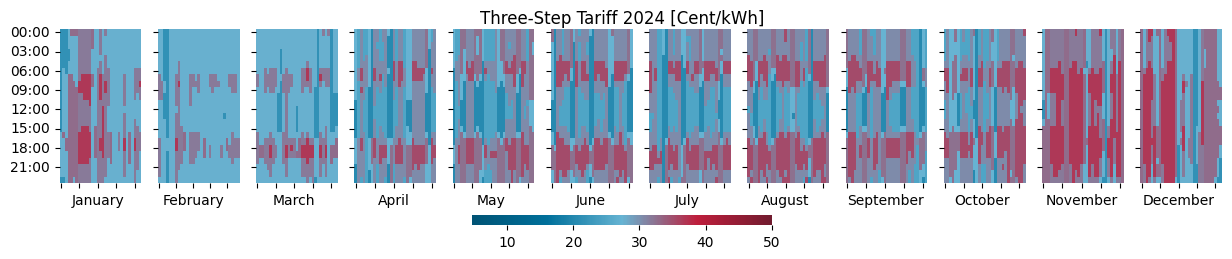

In [46]:
'''
Visualisierung
'''
import math
import matplotlib.pyplot as plt

import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm, ListedColormap

import elenia_cmap
elenia_cmap.register_elenia_colormaps()

df = pd.read_csv(r'C:\Users\fu\Downloads\Dokumente\Smart Tariffe\TG\Datenanalyse\TG_Datenanalyser\result_ohne_Dauer_2024.csv', index_col=[0])
prices.index = pd.to_datetime(prices.index)
df.index = prices.index

#df = df.loc['2024']
#df = df.loc['2023']

df['3-step'] = df['tariff'].astype(float)
df['dynamic'] = df['Wholesale price corrected'].astype(float)
#month_names = ["Januar", "Februar", "März", "April", "Mai",  "Juni", "Juli", "August", "September", "Oktober", "November", "Dezember"]
month_names = ["January", "February", "March", "April", "May",  "June", "July", "August", "September", "October", "November", "December"]
df["Date"] = pd.to_datetime(df.index.date)
df["Time"] = df.index.time

fig, ax = plt.subplots(ncols=12, sharey=True, figsize=(15, 2))
# cbar_ax = fig.add_axes([0.2, -0.1, 0.6, 0.05])
cbar_ax = fig.add_axes([0.4, -0.1, 0.2, 0.05])
# colors = ["#043e57", "#064e6d", "#0a5d81", "#096992", "#1c7ea7", "#41a6ce", "#61c0e6", "#a06471", "#9f485b", "#93384d", "#811d34", "#711c2f"]
# boundaries = sorted([i for sub in list(levels.values()) for i in sub]) + [math.ceil(max(max(p) for p in levels.values()))]
# cmap = ListedColormap(colors)
# norm = BoundaryNorm(boundaries, ncolors=len(colors), extend='neither')

for i, (month, group) in enumerate(df.groupby(df["Date"].dt.month)):
    group["hour_time"] = group["Time"].apply(lambda x: x.strftime("%H:%M"))
    month_data = group.pivot_table(index="hour_time", columns="Date", values="tariff")
    month_data.columns = [x.strftime("%Y-%m-%d") for x in month_data.columns]

    sns.heatmap(
        month_data,
        cmap='prim_elenia_int',
        # norm=norm,
        ax=ax[i],
        cbar_ax=cbar_ax,
        # cbar_kws={"orientation": "horizontal", "ticks": boundaries},
        cbar_kws={"orientation": "horizontal"},
        vmin=df["dynamic"].min(),
        vmax=df["dynamic"].quantile(0.992),
    )
    ax[i].set_ylabel("")
    labels = ax[i].get_xticklabels()
    mid = round(len(labels) / 2)
    for j, label in enumerate(labels):
        if j == mid:
            label.set_text(f"{month_names[month - 1]}")
        if j != mid:
            label.set_text("")
            labels[j] = label
    ax[i].set_xticklabels(labels, rotation=0)

fig.suptitle("Three-Step Tariff 2024 [Cent/kWh]")
plt.savefig('C:/Users/fu/Downloads/Dokumente/Smart Tariffe/TG/Datenanalyse/TG_Datenanalyser/Pictures/Heatmap 2024 Industrie 3_step.png', dpi=300, bbox_inches='tight')

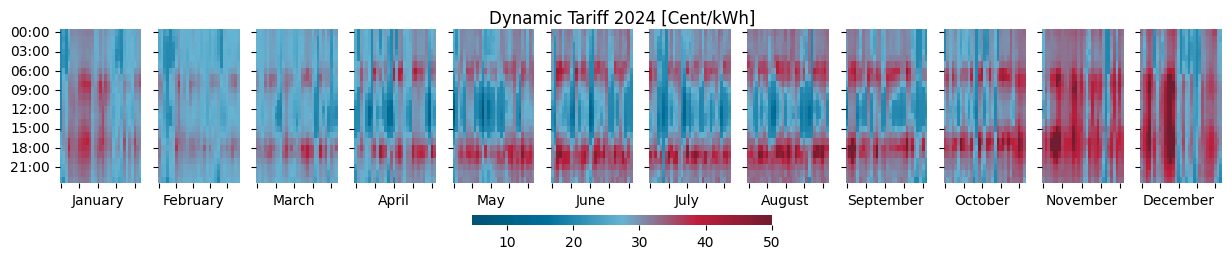

In [47]:
"""
dynamic chart from elenia
"""

fig, ax = plt.subplots(ncols=12, sharey=True, figsize=(15, 2))
cbar_ax = fig.add_axes([0.4, -0.1, 0.2, 0.05])

for i, (month, group) in enumerate(df.groupby(df["Date"].dt.month)):
    # Extract data for the current month
    group["Time"] = group["Time"].apply(lambda x: x.strftime("%H:%M"))
    month_data = group.pivot(index="Time", columns="Date", values="dynamic")
    month_data.columns = [x.strftime("%Y-%m") for x in month_data.columns]

    # Plot using the new colormap
    sns.heatmap(
        month_data,
        cmap="prim_elenia_int",
        ax=ax[i],
        cbar_ax=cbar_ax,
        cbar_kws={"orientation": "horizontal"},
        vmin=df["dynamic"].min(),
        vmax=df["dynamic"].quantile(0.992),
    )
    ax[i].set_ylabel("")
    labels = ax[i].get_xticklabels()
    mid = round(len(labels) / 2)
    for j, label in enumerate(labels):
        if j == mid:
            label.set_text(f"{month_names[month-1]}")
        if j != mid:
            label.set_text("")
            labels[j] = label
    ax[i].set_xticklabels(labels, rotation=0)

fig.suptitle("Dynamic Tariff 2024 [Cent/kWh]")
plt.savefig('C:/Users/fu/Downloads/Dokumente/Smart Tariffe/TG/Datenanalyse/TG_Datenanalyser/Pictures/Heatmap 2024 Industrie Dynamisch.png', dpi=300, bbox_inches='tight')

In [5]:
'''
Kosten Berechnung
'''
import pandas as pd

# Lastprofil für 2024 erstellen
time_index_h = pd.date_range(start='2024-01-01', end='2024-12-31 23:00:00', freq='H')
time_index_q = pd.date_range(start='2024-01-01', end='2024-12-31 23:45:00', freq='15T')

## opsd load profile ##
# last_opsd = pd.read_csv(r'\\fserv02.hochschule-bc.de\HBCDaten\EI-IGE\FuE_Projekte\72234016_KEMAL\Datenressourcen\OpenPowerSystem\household_data_60min_singleindex.csv')
# # last_opsd = last_opsd.loc[18032:26791, ['DE_KN_residential4_grid_import']] # residential5 is apartment
# last_opsd = last_opsd.loc[18032:26815, ['DE_KN_residential5_grid_import']] # 24 more values for 366 days per year
# last_opsd['Energie in kWh'] = last_opsd['DE_KN_residential5_grid_import'].diff().fillna(0)
# last_opsd.index = time_index_h
# last_opsd.index.name = 'Datum'

## Standard load profile ##
# last = pd.read_excel(r'C:\Users\fu\Downloads\Dokumente\Smart Tariffe\TG\LastProfilen\Standardlastgangsynthese Strom 2024.xlsx', sheet_name='Ausgabe ')
# last['Datum '] = pd.to_datetime(last['Datum '])
# last.set_index('Datum ', inplace=True)

## Alois Müller Lastprofil
last_AM = pd.read_csv(r'C:\Users\fu\Downloads\Dokumente\Smart Tariffe\TG\EnMPRO_2022-2024-04_Netz-BHKW-PV_corrected.csv', sep=';')
last_AM = last_AM.loc[34798:69933, ['a_NSHVT_P400_Hauptmessung_Werksgelaende_P']] # one more day for 366 days in 2024
last_AM['Energie in kWh'] = last_AM['a_NSHVT_P400_Hauptmessung_Werksgelaende_P'] / 4
last_AM.index = time_index_q
last_AM.index.name = 'Datum'

# HERE to choose which Lastprofil
last = last_AM
# hourly_last = last['Energie in kWh'].resample('H').sum()
hourly_last = last['Energie in kWh']

tariff = pd.read_csv(r'C:\Users\fu\Downloads\Dokumente\Smart Tariffe\TG\Datenanalyse\TG_Datenanalyser\result_ohne_Dauer_2024_Industrie.csv', index_col=[0])
tariff.index = pd.to_datetime(prices.index)
### resample tariff to 15-minute
# tariff = tariff.resample('15T').ffill()

tariff['hourly_last'] = hourly_last
# tariff['Kosten_Stufen'] = tariff['tariff'] * hourly_last * 0.01
# tariff['Kosten_Dynamic'] = tariff['Wholesale price corrected'] * hourly_last * 0.01
# tariff['Kosten_Ein'] = 32 * hourly_last * 0.01
tariff['Kosten_Stufen'] = tariff.apply(lambda row: row['hourly_last'] * row['tariff'] * 0.01 if row['hourly_last'] > 0\
                                       else row['hourly_last'] * 7.92 * 0.01, axis=1)
tariff['Kosten_Dynamic'] = tariff.apply(lambda row: row['hourly_last'] * row['Wholesale price corrected'] * 0.01 if row['hourly_last'] > 0\
                                       else row['hourly_last'] * 7.92 * 0.01, axis=1)
tariff['Kosten_Ein'] = tariff.apply(lambda row: row['hourly_last'] * 35 * 0.01 if row['hourly_last'] > 0\
                                       else row['hourly_last'] * 7.92 * 0.01, axis=1)
# tariff.to_csv(r'C:\Users\fu\Downloads\Dokumente\Smart Tariffe\TG\Datenanalyse\TG_Datenanalyser\Kosten_result_ohne_Dauer_2024_AM_15min.csv')

summer = tariff.loc['2024-04-01':'2024-10-31']
winter = pd.concat([tariff.loc['2024-01-01':'2024-03-31'], tariff.loc['2024-11-01':'2024-12-31']])
print('yearly consumption: ', hourly_last.sum())
# print('negative Energie: ', hourly_last[hourly_last < 0].sum())
# print('positive Energie: ', hourly_last[hourly_last > 0].sum())

print('total cost dynamic: ', tariff['Kosten_Dynamic'].sum())
# print('summer cost dynamic: ', summer['Kosten_Dynamic'].sum())
# print('winter cost dynamic: ', winter['Kosten_Dynamic'].sum())

print('total cost 3 Stufen: ', tariff['Kosten_Stufen'].sum())
# print('Bezugskosten: ', (tariff['Kosten_Stufen'][tariff['Kosten_Stufen'] > 0]).sum())
# print('Erlöse: ', (tariff['Kosten_Stufen'][tariff['Kosten_Stufen'] < 0]).sum())
# print('summer cost 3 Stufen: ', summer['Kosten_Stufen'].sum())
# print('winter cost 3 Stufen: ', winter['Kosten_Stufen'].sum())

print('total cost Ein Tarif: ', tariff['Kosten_Ein'].sum())
# print('summer cost Ein Tarif: ', summer['Kosten_Ein'].sum())
# print('winter cost Ein Tarif: ', winter['Kosten_Ein'].sum())

yearly consumption:  -923027.075
total cost dynamic:  -15033.446631750001
total cost 3 Stufen:  -15512.012875
total cost Ein Tarif:  -10574.3092
